# **A04 - Análisis de residuos**

---
Nombre: **Alan Jesús Hernández Soto** \
Carrera: **Ingeniería Financiera** \
Materia: **Laboratorio de Aprendizaje Estadístico** \
Tipo de Trabajo: **Actividad**

---

## Índice

1. Tratamiento de datos
2. Regresión lineal inicial
3. Análisis de residuos
4. Regresión múltiple final
5. Conclusión

## 1. Tratamiento de datos

Se carga el conjunto de datos *College*, se revisa su estructura y se preparan las variables necesarias para estimar el modelo.

**Importación de librerías**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd

**Carga, exploración y tratamiento de datos**

Se elimina la columna de índice y se codificaa variable *Private* para poder utilizarla en la regresión.

In [2]:
df = pd.read_csv('Datasets/College.csv')
df.head(5)

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 777 entries, 0 to 776
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   777 non-null    object 
 1   Private      777 non-null    object 
 2   Apps         777 non-null    int64  
 3   Accept       777 non-null    int64  
 4   Enroll       777 non-null    int64  
 5   Top10perc    777 non-null    int64  
 6   Top25perc    777 non-null    int64  
 7   F.Undergrad  777 non-null    int64  
 8   P.Undergrad  777 non-null    int64  
 9   Outstate     777 non-null    int64  
 10  Room.Board   777 non-null    int64  
 11  Books        777 non-null    int64  
 12  Personal     777 non-null    int64  
 13  PhD          777 non-null    int64  
 14  Terminal     777 non-null    int64  
 15  S.F.Ratio    777 non-null    float64
 16  perc.alumni  777 non-null    int64  
 17  Expend       777 non-null    int64  
 18  Grad.Rate    777 non-null    int64  
dtypes: float

In [4]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [5]:
df['Private'] = df['Private'].map({'Yes': 1, 'No': 0})
df

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,1,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,1,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,1,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,1,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,1,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,0,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,1,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,1,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,1,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


## 2. Regresión lineal inicial

Se estima una regresión lineal múltiple para explicar la tasa de graduación (*Grad.Rate*) a partir de las variables disponibles.

**Estimación con Statsmodels**

In [6]:
df['Private_Expend'] = df['Private'] * df['Expend']

X = df.drop(columns=['Grad.Rate'])
Y = df['Grad.Rate']
X = sm.add_constant(X)


model = sm.OLS(Y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.462
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     36.10
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           3.09e-89
Time:                        19:22:11   Log-Likelihood:                -3071.0
No. Observations:                 777   AIC:                             6180.
Df Residuals:                     758   BIC:                             6268.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             34.3947      5.773      5.957      0.000      23.061      45.729
Private            2.9443      3.127      0.942      0.347      -3.195       9.083
Apps               0.0013      0.000      2.942      0.003       0.000       0.002
Accept            -0.0007      0.001     -0.802      0.423      -0.002       0.001
Enroll             0.0021      0.002      0.915      0.361      -0.002       0.007
Top10perc          0.0553      0.072      0.770      0.442      -0.086       0.196
Top25perc          0.1351      0.055      2.456      0.014       0.027       0.243
F.Undergrad       -0.0005      0.000     -1.137      0.256      -0.001       0.000
P.Undergrad       -0.0015      0.000     -3.752      0.000      -0.002      -0.001
Outstate           0.0010      0.000      4.324      0.000       0.001       0.001
Room.Board         0.0019      0.001      3.240      0.001       0.001       0.003
Books             -0.0022      0.003     -0.749      0.454      -0.008       0.004
Personal          -0.0017      0.001     -2.165      0.031      -0.003      -0.000
PhD                0.0879      0.057      1.543      0.123      -0.024       0.200
Terminal          -0.0749      0.062     -1.201      0.230      -0.197       0.048
S.F.Ratio          0.0676      0.167      0.405      0.686      -0.260       0.395
perc.alumni        0.2790      0.049      5.665      0.000       0.182       0.376
Expend            -0.0005      0.000     -1.253      0.211      -0.001       0.000
Private_Expend  6.434e-05      0.000      0.166      0.868      -0.001       0.001
==============================================================================
Omnibus:                       36.213   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               97.024
Skew:                           0.163   Prob(JB):                     8.54e-22
Kurtosis:                       4.700   Cond. No.                     2.59e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.59e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Validación con scikit-learn**

In [7]:
X = X.drop(columns=['const'])

In [8]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X, Y)
y_pred = lr.predict(X)
lr.score(X, Y)

0.46156022221469617

## 3. Análisis de residuos

Se evalúan seis problemas comunes de la regresión lineal para verificar los supuestos del modelo e identificar observaciones o variables que requieren tratamiento.

**No linealidad de los datos**

La no linealidad ocurre cuando la relación entre los predictores y la respuesta no puede describirse adecuadamente con una recta. En la gráfica de residuos no se aprecia una forma/curva significativa, por lo que no fue necesario corregir este aspecto.

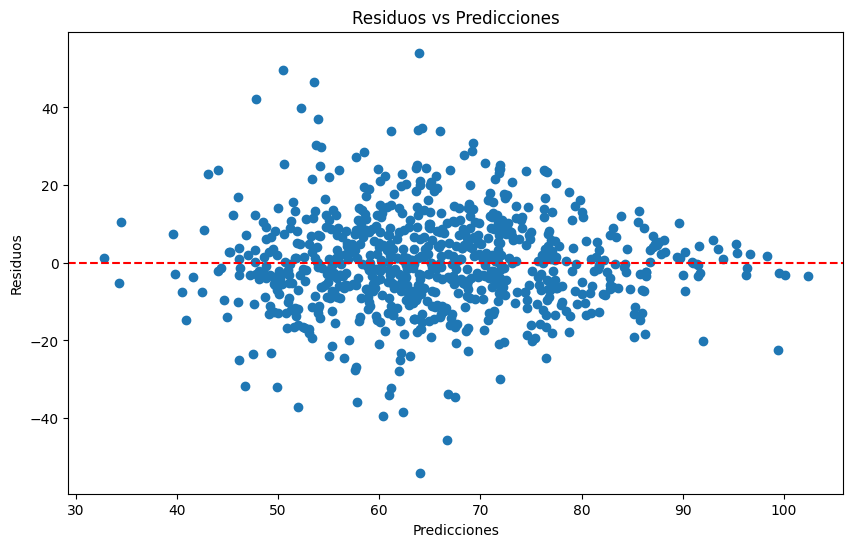

In [9]:
E = Y - y_pred
plt.figure(figsize=(10, 6))
plt.axhline(y=0, color='red', linestyle='--')
plt.scatter(y_pred, E)
plt.title('Residuos vs Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.show()

Los residuos se distribuyen alrededor de cero y no muestran un patrón curvo evidente; por lo tanto, el modelo lineal parece capturar adecuadamente la relación principal.

**Correlación en errores**

La correlación en errores aparece cuando los residuos de distintas observaciones no son independientes. Al revisar los errores según el orden se identifica un patrón, así que no fue necesario aplicar una corrección.

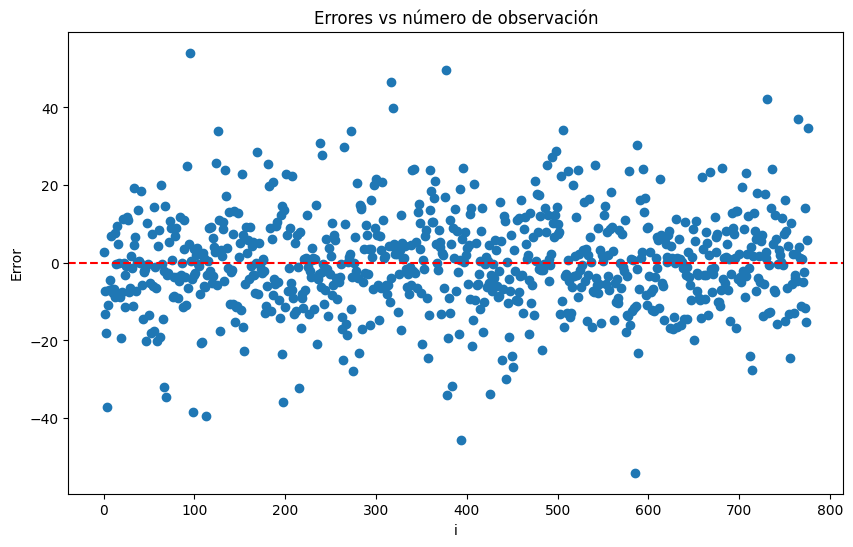

In [10]:
i = np.arange(len(E))

plt.figure(figsize=(10, 6))
plt.axhline(y=0, color='red', linestyle='--')
plt.scatter(i, E)
plt.title('Errores vs número de observación')
plt.xlabel('i')
plt.ylabel('Error')
plt.show()

**Heterocedasticidad**

La heterocedasticidad es una varianza no constante de los errores a lo largo de los valores ajustados. La dispersión se mantiene aproximadamente estable; los casos aislados se revisan como posibles valores atípicos, sin requerir una corrección específica de varianza.

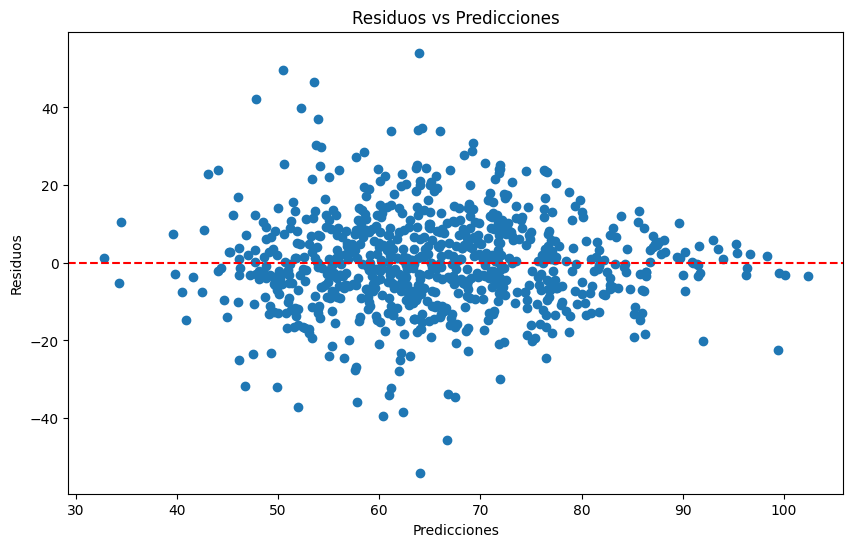

In [11]:
plt.figure(figsize=(10, 6))
plt.axhline(y=0, color='red', linestyle='--')
plt.scatter(y_pred, E)
plt.title('Residuos vs Predicciones')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.show()

La varianza de los residuos se mantiene aproximadamente constante; los puntos alejados del resto se evalúan en la siguiente sección como posibles valores atípicos.

**Valores atípicos**

Un valor atípico es una observación con una respuesta o un residuo inusualmente alejado del comportamiento general. Se identifican mediante residuos estandarizados con valor absoluto mayor o igual a 3 y se eliminan del conjunto de datos.

In [12]:
df['Predicciones'] = y_pred
df['Error'] = df['Grad.Rate'] - df['Predicciones']
df['Prueba'] = np.abs(df['Error'])/np.std(df['Error'])
df[df['Prueba'] >= 3]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,...,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Private_Expend,Predicciones,Error,Prueba
95,1,3847,3433,527,9,35,1010,12,9384,4840,...,22,47,14.3,20,7697,118,7697,63.916634,54.083366,4.293481
98,1,369,312,90,12,46,396,526,11400,5400,...,41,85,9.5,20,9583,24,9583,62.340098,-38.340098,3.043680
113,1,1196,697,499,21,47,959,13,4412,2460,...,69,69,16.9,31,7083,21,7083,60.399584,-39.399584,3.127789
317,1,810,484,356,6,33,2155,191,9200,4800,...,65,85,24.1,9,3480,100,3480,53.553186,46.446814,3.687243
319,1,900,473,217,22,47,621,11,4400,3400,...,53,93,10.4,16,9268,92,9268,52.258549,39.741451,3.154929
377,0,1576,1326,913,13,50,3689,2200,3840,2852,...,52,54,20.3,9,4172,100,0,50.479736,49.520264,3.931233
394,1,325,284,95,16,33,364,88,9900,3650,...,32,37,13.6,43,6525,21,6525,66.724173,-45.724173,3.629875
585,0,4345,3245,2604,15,85,5584,3101,7860,3360,...,65,75,18.2,21,3605,10,0,64.055520,-54.055520,4.291270
731,1,280,143,79,5,27,327,110,5590,2900,...,53,63,15.1,4,4839,90,4839,47.794669,42.205331,3.350527


Se identifican nueve valores atípicos; por ello, se eliminan las observaciones asociadas antes de volver a estimar el modelo.

In [13]:
df = df[df['Prueba'] < 3]
df.drop(columns=['Predicciones', 'Error', 'Prueba'], inplace=True)
df.shape

C:\Users\1\AppData\Local\Temp\ipykernel_11632\4271468370.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['Predicciones', 'Error', 'Prueba'], inplace=True)


(768, 19)

**Puntos palanca en X**

Un punto palanca es una observación con valores de los predictores inusualmente alejados del centro de los datos; por ello, puede influir de forma importante en la recta estimada. Se detectan con el valor de palanca y se eliminan las observaciones que superan el límite definido.

In [14]:
X = df.drop(columns=['Grad.Rate'])
n = len(df)
p = X.shape[1] + 1
limite = (p + 1) / n

hi = pd.DataFrame(index=df.index)
for i in X.columns:
    x = X[i]
    hi[i] = 1/n + (x - x.mean())**2 / ((x - x.mean())**2).sum()

list_pp = []
for i in hi.columns:
    pp = hi[hi[i] >= limite].index
    pp = pp.to_list()
    for j in pp:
        if j not in list_pp:
            list_pp.append(j)
list_pp.sort()
print(len(list_pp))

df = df.drop(index=list_pp)
df.shape

36


(732, 19)

**Colinealidad**

La colinealidad ocurre cuando dos o más predictores están fuertemente relacionados entre sí, lo que vuelve inestables los coeficientes del modelo. Se calcula el factor de inflación de la varianza (VIF) y se eliminan las variables con VIF mayor o igual a 10. Se tomo esta decisión porque eliminar el VIF>5 disminuyo el score de la regresión original.

In [15]:
vif = pd.DataFrame(index=X.columns, columns=['R2', 'VIF'])

for i in X.columns:
    X_j = X[i]
    X_resto = X.drop(columns=[i])
    X_resto = sm.add_constant(X_resto)
    m = sm.OLS(X_j, X_resto).fit()
    R2 = m.rsquared
    vif.loc[i, 'R2'] = R2
    vif.loc[i, 'VIF'] = 1 / (1 - R2)

col_vif = vif[vif['VIF'] >= 10].index
col_vif = col_vif.tolist()
df = df.drop(columns=col_vif)

print('Columnas eliminadas:', col_vif)

Columnas eliminadas: ['Apps', 'Accept', 'Enroll', 'F.Undergrad', 'Expend', 'Private_Expend']


## 4. Regresión múltiple final

Se vuelve a estimar la regresión después de tratar los valores atípicos, los puntos palanca en X y las variables con colinealidad elevada.

In [16]:
X = df.drop(columns=['Grad.Rate'])
Y = df['Grad.Rate']

X = sm.add_constant(X)
sm.OLS(Y, X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Grad.Rate   R-squared:                       0.471
Model:                            OLS   Adj. R-squared:                  0.462
Method:                 Least Squares   F-statistic:                     53.39
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           4.09e-91
Time:                        19:22:12   Log-Likelihood:                -2854.1
No. Observations:                 732   AIC:                             5734.
Df Residuals:                     719   BIC:                             5794.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          29.4945      4.759      6.198      0.000      20.151      38.837
Private         1.1129      1.538      0.724      0.470      -1.907       4.132
Top10perc       0.0249      0.062      0.399      0.690      -0.098       0.147
Top25perc       0.1997      0.053      3.802      0.000       0.097       0.303
P.Undergrad    -0.0011      0.001     -2.049      0.041      -0.002   -4.62e-05
Outstate        0.0009      0.000      4.403      0.000       0.001       0.001
Room.Board      0.0023      0.001      4.150      0.000       0.001       0.003
Books          -0.0058      0.004     -1.590      0.112      -0.013       0.001
Personal       -0.0021      0.001     -2.525      0.012      -0.004      -0.000
PhD             0.1172      0.056      2.079      0.038       0.007       0.228
Terminal       -0.1422      0.061     -2.314      0.021      -0.263      -0.022
S.F.Ratio       0.4162      0.153      2.728      0.007       0.117       0.716
perc.alumni     0.3016      0.048      6.312      0.000       0.208       0.395
==============================================================================
Omnibus:                        6.153   Durbin-Watson:                   2.048
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                6.278
Skew:                           0.173   Prob(JB):                       0.0433
Kurtosis:                       3.293   Cond. No.                     1.30e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.3e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [17]:
X = X.drop(columns=['const'])
lr.fit(X, Y)
lr.score(X, Y)

0.47120439917002

## 5. Conclusión

El diagnóstico no mostró evidencia suficiente de no linealidad, correlación en errores ni heterocedasticidad para justificar un ajuste. En cambio, se corrigieron los valores atípicos, los puntos palanca en X y la colinealidad antes de estimar la regresión múltiple final. Es de observar que el score aumento 1.1 puntos porcentuales por lo tanto no es un gran cambio, ademas de que ambos son menores que 50 indicando que el modelo no es tan bueno.